In [ ]:
!pip install gdown
!pip install -q transformers torch sentencepiece huggingface_hub underthesea

In [ ]:
import os
import re
import math
import random
import string
import warnings

import gdown
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Dense,
    Dropout,
    Flatten,
    BatchNormalization,
    SimpleRNN,
    LSTM,
    Bidirectional
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from underthesea import text_normalize
from tqdm import tqdm

warnings.filterwarnings('ignore')

2026-05-14 09:04:39.325687: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778749479.724794      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778749479.838245      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778749480.824250      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778749480.824299      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778749480.824303      23 computation_placer.cc:177] computation placer alr

In [3]:
# URL gốc trên Google Drive 
URLS = {
    "train": {
        "sentences": "https://drive.google.com/uc?id=1nzak5OkrheRV1ltOGCXkT671bmjODLhP",
        "sentiments": "https://drive.google.com/uc?id=1ye-gOZIBqXdKOoi_YxvpT6FeRNmViPPv",
        "topics": "https://drive.google.com/uc?id=14MuDtwMnNOcr4z_8KdpxprjbwaQ7lJ_C",
    },
    "validation": {
        "sentences": "https://drive.google.com/uc?id=1sMJSR3oRfPc3fe1gK-V3W5F24tov_517",
        "sentiments": "https://drive.google.com/uc?id=1GiY1AOp41dLXIIkgES4422AuDwmbUseL",
        "topics": "https://drive.google.com/uc?id=1DwLgDEaFWQe8mOd7EpF-xqMEbDLfdT-W",
    },
    "test": {
        "sentences": "https://drive.google.com/uc?id=1aNMOeZZbNwSRkjyCWAGtNCMa3YrshR-n",
        "sentiments": "https://drive.google.com/uc?id=1vkQS5gI0is4ACU58-AbWusnemw7KZNfO",
        "topics": "https://drive.google.com/uc?id=1_ArMpDguVsbUGl-xSMkTF_p5KpZrmpSB",
    },
}

TRAIN_PATH = "/kaggle/input/datasets/gnart20044/train-val-relabled/train_final.csv"
VAL_PATH = "/kaggle/input/datasets/gnart20044/train-val-relabled/val_final.csv"
TEST_PATH = "/kaggle/input/datasets/gnart20044/train-val-relabled/test_final.csv"

# Tải và đọc từng split 
def load_split(name, urls):
    files = {}
    for k, url in urls.items():
        output = f"{name}_{k}.txt"
        gdown.download(url, output, quiet=True)
        files[k] = output

    # Đọc 3 file và gộp lại
    with open(files["sentences"], encoding="utf-8") as f:
        sentences = [line.strip() for line in f]
    with open(files["sentiments"], encoding="utf-8") as f:
        sentiments = [int(line.strip()) for line in f]
    with open(files["topics"], encoding="utf-8") as f:
        topics = [int(line.strip()) for line in f]

    return pd.DataFrame({
        "sentence": sentences,
        "sentiment": sentiments,
        "topic": topics
    })

# Tải từng tập
train_df = load_split("train", URLS["train"])
val_df   = load_split("val", URLS["validation"])
test_df  = load_split("test", URLS["test"])

def load_data_from_csv():
    try:
        # Load file đã cập nhật nhãn
        train_df = pd.read_csv(TRAIN_PATH)
        val_df = pd.read_csv(VAL_PATH)
        test_df1 = pd.read_csv(TEST_PATH)
        
        print("--- Thông tin dữ liệu đã load ---")
        print(f"Tập Train: {len(train_df)} mẫu")
        print(f"Tập Val  : {len(val_df)} mẫu")
        print(f"Tập Test  : {len(test_df1)} mẫu")
        
        
        # return train_df, val_df, test_df1
        return test_df1
    
    except FileNotFoundError as e:
        print(f"Lỗi: Không tìm thấy file. Hãy chắc chắn bạn đã chạy bước xuất CSV trước đó. \nChi tiết: {e}")
        return None, None

# 2. Thực thi load dữ liệu
# train_df, val_df, test_df1 = load_data_from_csv()
test_df1 = load_data_from_csv()

--- Thông tin dữ liệu đã load ---
Tập Train: 11426 mẫu
Tập Val  : 1583 mẫu
Tập Test  : 3166 mẫu


# Preprocessing

In [ ]:
def load_external_teencode(file_path):
    """Hàm đọc file teencode.txt từ Kaggle và chuyển thành Dictionary"""
    external_dict = {}
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                # Thông thường file teencode.txt trên Kaggle phân tách bằng dấu Tab (\t)
                # Nếu file dùng định dạng khác (như dấu phẩy), hãy đổi split('\t') thành split(',')
                parts = line.strip().split('\t') 
                if len(parts) >= 2:
                    teencode = parts[0].strip().lower()
                    standard = parts[1].strip().lower()
                    external_dict[teencode] = standard
        print(f"Đã tải thành công {len(external_dict)} từ teencode từ file Kaggle.")
    except Exception as e:
        print(f"Lỗi khi đọc file teencode: {e}")
    return external_dict

# Từ điển giải mã Emoticon đặc thù của dữ liệu UIT-VSFC
UIT_VSFC_EMOTICON_DICT = {
    "colonsmilesmile": "rất vui", "colondoublesurprise": "rất bất ngờ",
    "colonbigsmile": "cười to", "colonsadcolon": "rất buồn",
    "colonsmalsmile": "mỉm cười", "colonsmile": "vui vẻ",
    "colonlove": "yêu thích", "colonsad": "buồn bã",
    "colonhihi": "vui vẻ", "coloncontemn": "chê bai",
    "coloncolon": "bối rối" 
}

# Từ điển tự định nghĩa (Mang tính cục bộ của môi trường đại học)
CUSTOM_TEENCODE_DICT = {
    "ko": "không", "k": "không", "kh": "không", "khg": "không", "kg": "không",
    "dc": "được", "đc": "được", "duoc": "được",
    "sv": "sinh viên", "gv": "giảng viên", "thầy cô": "giảng viên",
    "vs": "với", "r": "rồi", "ah": "à", "nhìu": "nhiều",
    "bt": "bình thường", "tot": "tốt", "thik": "thích", 
    "ntn": "như thế nào", "nv": "nhân viên", "cs vc": "cơ sở vật chất",
    "csvc": "cơ sở vật chất", "wifi": "mạng", "phong": "phòng", "vkl": "vô cùng",
    "vl": "vô cùng", "vcl": "vô cùng", "đm": "chửi thề", "vãi": "rất"
}

# Tiến hành hợp nhất 2 từ điển
KAGGLE_FILE_PATH = '/kaggle/input/datasets/taiduong1/vietnamese-teencode/teencode.txt'

# Bước 1: Load file gốc
FINAL_TEENCODE_DICT = load_external_teencode(KAGGLE_FILE_PATH)

# Bước 2: Dùng lệnh .update() để hợp nhất. 
# Từ điển CUSTOM sẽ ghi đè lên EXTERNAL nếu có các key trùng lặp.
FINAL_TEENCODE_DICT.update(CUSTOM_TEENCODE_DICT)

print(f"Tổng số từ khóa teencode hiện có trong bộ lọc: {len(FINAL_TEENCODE_DICT)}")

def clean_vietnamese_text(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Dùng thư viện ngoài để chuẩn hóa Unicode
    text = text_normalize(text).lower()
    
    # 2. Giải mã các chuỗi emoticon đặc thù
    for encoded_emo, meaning in UIT_VSFC_EMOTICON_DICT.items():
        text = re.sub(r'\b' + re.escape(encoded_emo) + r'\b', f" {meaning} ", text)
        
    # 3. Chuẩn hóa Teencode bằng TỪ ĐIỂN ĐÃ HỢP NHẤT
    for word, true_word in FINAL_TEENCODE_DICT.items():
        text = re.sub(r'\b' + re.escape(word) + r'\b', f" {true_word} ", text)
        
    # 4. Loại bỏ dấu câu (Punctuation)
    punctuations = string.punctuation + '”’“‘…—'
    for p in punctuations:
        text = text.replace(p, ' ')
        
    # 5. Loại bỏ kí tự rác (Chỉ giữ chữ cái tiếng Việt, số, khoảng trắng)
    text = re.sub(r'[^\s\wáàảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵđ]', ' ', text)
    
    # 6. Chuẩn hóa khoảng trắng liên tiếp
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

train_df['cleaned_text'] = train_df['sentence'].apply(clean_vietnamese_text)
val_df['cleaned_text'] = val_df['sentence'].apply(clean_vietnamese_text)
test_df['cleaned_text'] = test_df['sentence'].apply(clean_vietnamese_text)
test_df1['cleaned_text'] = test_df1['sentence'].apply(clean_vietnamese_text)

Đã tải thành công 389 từ teencode từ file Kaggle.
Tổng số từ khóa teencode hiện có trong bộ lọc: 406


# B0 baseline singletask 

In [ ]:
# config
MODEL_NAME = "xlm-roberta-base"
MAX_LEN      = 128
BATCH_SIZE   = 16
ACCUM_STEPS = 2 # Gom 2 batch 16 = 32
LR           = 2e-5
EPOCHS       = 10
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_SENTIMENT = 3   # Negative=0, Neutral=1, Positive=2
NUM_TOPIC     = 4   # Lecturer=0, Training=1, Facility=2, Others=3

# Tên nhãn dùng nhất quán trong toàn bộ file
SENT_NAMES  = ["Negative", "Neutral", "Positive"]
TOPIC_NAMES = ["Lecturer", "Training Program", "Facility", "Others"]

print(f"Device: {DEVICE}")

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)

# tokenizer 
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# DATASET CLASS
class FeedbackDataset(Dataset):
    def __init__(self, sentences, sentiments, topics, tokenizer, max_len):
        self.sentences  = sentences
        self.sentiments = sentiments
        self.topics     = topics
        self.tokenizer  = tokenizer
        self.max_len    = max_len

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.sentences[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "sentiment":      torch.tensor(self.sentiments[idx], dtype=torch.long),
            "topic":          torch.tensor(self.topics[idx],     dtype=torch.long),
        }


def make_loader(df, shuffle=True):
    ds = FeedbackDataset(
        df["sentence"].tolist(),
        # df["sentence_seg"].tolist(), 
        df["sentiment"].tolist(),
        df["topic"].tolist(),
        tokenizer, MAX_LEN
    )
    return DataLoader(ds, batch_size=BATCH_SIZE,
                      shuffle=shuffle, num_workers=2, pin_memory=True)

train_loader = make_loader(train_df, shuffle=True)
val_loader   = make_loader(val_df,   shuffle=False)
test_loader  = make_loader(test_df,  shuffle=False)
test_loader1  = make_loader(test_df1,  shuffle=False)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)} | Test relabled: {len(test_df1)}")

# CLASS WEIGHTS 
def compute_class_weights(labels, num_classes):
    """Inverse frequency weighting."""
    counts = np.bincount(labels, minlength=num_classes).astype(float)
    weights = 1.0 / (counts + 1e-6)
    weights = weights / weights.sum() * num_classes   # normalize
    return torch.tensor(weights, dtype=torch.float32)

def compute_focal_alpha(labels: np.ndarray, num_classes: int) -> torch.Tensor:
    """
    Alpha cho Focal Loss.
    Normalize về sum = 1 (không nhân num_classes).
    """
    counts = np.bincount(labels, minlength=num_classes).astype(float)
    alpha  = 1.0 / (counts + 1e-8)
    alpha  = alpha / alpha.sum()
    return torch.tensor(alpha, dtype=torch.float32)
    
sent_weights  = compute_class_weights(train_df["sentiment"].values, NUM_SENTIMENT)
topic_weights = compute_class_weights(train_df["topic"].values,     NUM_TOPIC)
sent_focal_alpha  = compute_focal_alpha(train_df["sentiment"].values, NUM_SENTIMENT)
topic_focal_alpha = compute_focal_alpha(train_df["topic"].values,     NUM_TOPIC)
print("Sentiment weights:", sent_weights.round(decimals=3))
print("Topic weights    :", topic_weights.round(decimals=3))
print("Focal alpha  (sentiment):", sent_focal_alpha.numpy().round(4))
print("Focal alpha  (topic)    :", topic_focal_alpha.numpy().round(4))

def predict_test(model, loader, task):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids, mask = batch["input_ids"].to(DEVICE), batch["attention_mask"].to(DEVICE)
            logits = model(ids, mask)
            all_preds.extend(logits.argmax(-1).cpu().tolist())
            all_labels.extend(batch[task].tolist())
    return f1_score(all_labels, all_preds, average="macro"), all_labels, all_preds

def evaluate_and_plot(model, loader, task, target_names, title="Confusion Matrix"):
    model.eval()
    y_pred, y_true = [], []
    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            logits = model(ids, mask)
            y_pred.extend(logits.argmax(-1).cpu().tolist())
            y_true.extend(batch[task].tolist())
            
    print(f"\n=== {title.upper()} ===")
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()
    
    return classification_report(y_true, y_pred, target_names=target_names, digits=4, output_dict=True)

def plot_training_history(history_df, title="Training History"):
    if history_df is None or history_df.empty:
        print(f"Cannot plot '{title}': DataFrame is empty.")
        return
        
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Biểu đồ 1: Train Loss vs Val Loss
    ax1.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss', marker='o', color='tab:red')
    ax1.plot(history_df['epoch'], history_df['val_loss'], label='Val Loss', marker='s', color='tab:orange')
    ax1.set_title('Mức độ lỗi (Loss) qua các Epoch')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Cross-Entropy Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Biểu đồ 2: Train F1 vs Val F1
    ax2.plot(history_df['epoch'], history_df['train_f1'], label='Train Macro F1', marker='o', color='tab:blue')
    ax2.plot(history_df['epoch'], history_df['val_f1'], label='Val Macro F1', marker='s', color='tab:green')
    ax2.set_title('Độ chính xác (Macro F1) qua các Epoch')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Macro F1 Score')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Chẩn đoán trên tập val trước khi lưu test
def diagnose_validation_single_task(model, val_loader, model_name, task):
    """In Classification Report trực tiếp trên tập Validation để chẩn đoán lớp thiểu số cho Single-Task"""
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in val_loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            
            # Mô hình single-task chỉ trả về 1 logit
            logits = model(ids, mask)
            
            all_preds.extend(logits.argmax(-1).cpu().tolist())
            all_labels.extend(batch[task].tolist())

    print(f"\nChẩn đoán validation === {model_name} ({task.upper()}) ===")
    
    if task == "sentiment":
        target_names = ["Negative", "Neutral", "Positive"]
    elif task == "topic":
        target_names = ["Lecturer", "Training", "Facility", "Others"]
    else:
        target_names = None
        
    print(classification_report(all_labels, all_preds, target_names=target_names, digits=4))

Device: cuda


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 11426 | Val: 1583 | Test: 3166 | Test relabled: 3166
Sentiment weights: tensor([0.2210, 2.5700, 0.2090])
Topic weights    : tensor([0.1120, 0.4160, 1.8420, 1.6290])
Focal alpha  (sentiment): [0.0737 0.8568 0.0695]
Focal alpha  (topic)    : [0.028  0.104  0.4606 0.4073]


In [ ]:
# Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha, gamma=2.0):
        super().__init__()
        self.alpha = alpha   # tensor shape [num_classes]
        self.gamma = gamma
        
    def forward(self, logits, targets):
        # Cross-entropy từng sample, không reduction
        ce = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce)                      # xác suất đúng
        alpha_t = self.alpha.to(logits.device)[targets]
        fl = alpha_t * (1 - pt) ** self.gamma * ce
        return fl.mean()

class ClassSpecificAsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg_list, gamma_pos_list, clip=0.05, eps=1e-8):
        super(ClassSpecificAsymmetricLoss, self).__init__()
        self.register_buffer('gamma_neg', torch.tensor(gamma_neg_list, dtype=torch.float32))
        self.register_buffer('gamma_pos', torch.tensor(gamma_pos_list, dtype=torch.float32))
        self.clip = clip
        self.eps = eps

    def forward(self, x, y):
        num_classes = x.size(1)
        y_onehot = F.one_hot(y, num_classes=num_classes).float()
        
        # Dùng sigmoid thay vì softmax
        xs_pos = torch.sigmoid(x)
        xs_neg = 1.0 - xs_pos
        
        # Probability shifting
        if self.clip is not None and self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1)

        # Cross Entropy cơ bản
        los_pos = y_onehot * torch.log(xs_pos.clamp(min=self.eps))
        los_neg = (1 - y_onehot) * torch.log(xs_neg.clamp(min=self.eps))
         # Mở rộng ma trận Gamma
        gamma_pos_t = self.gamma_pos.unsqueeze(0).expand_as(x)
        gamma_neg_t = self.gamma_neg.unsqueeze(0).expand_as(x)

        # Tính xác suất tổng hợp và Gamma tương ứng
        pt = (xs_pos * y_onehot) + (xs_neg * (1 - y_onehot))
        one_sided_gamma = (gamma_pos_t * y_onehot) + (gamma_neg_t * (1 - y_onehot))
        
        # Trọng số Asymmetric
        one_sided_w = torch.pow(1 - pt, one_sided_gamma)
        
        loss = -(los_pos + los_neg) * one_sided_w
        return loss.sum(dim=-1).mean()


B0 (CE): Single Task - Standard Cross Entropy


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.6370 | Val Loss: 0.3042 | Train F1: 0.5250 | Val F1: 0.6269
New best (Val F1: 0.6269)
Epoch 02 | Train Loss: 0.2610 | Val Loss: 0.3246 | Train F1: 0.7262 | Val F1: 0.7128
New best (Val F1: 0.7128)
Epoch 03 | Train Loss: 0.2080 | Val Loss: 0.2670 | Train F1: 0.8206 | Val F1: 0.7720
New best (Val F1: 0.7720)
Epoch 04 | Train Loss: 0.1648 | Val Loss: 0.2640 | Train F1: 0.8591 | Val F1: 0.8314
New best (Val F1: 0.8314)
Epoch 05 | Train Loss: 0.1285 | Val Loss: 0.2568 | Train F1: 0.8866 | Val F1: 0.8541
New best (Val F1: 0.8541)
Epoch 06 | Train Loss: 0.1096 | Val Loss: 0.2868 | Train F1: 0.9139 | Val F1: 0.8409
Không cải thiện 1/3
Epoch 07 | Train Loss: 0.0853 | Val Loss: 0.3260 | Train F1: 0.9417 | Val F1: 0.8422
Không cải thiện 2/3
Epoch 08 | Train Loss: 0.0691 | Val Loss: 0.3713 | Train F1: 0.9580 | Val F1: 0.8349
Không cải thiện 3/3
Early stopping tại epoch 8!

Best validation sentiment Macro F1: 0.8541


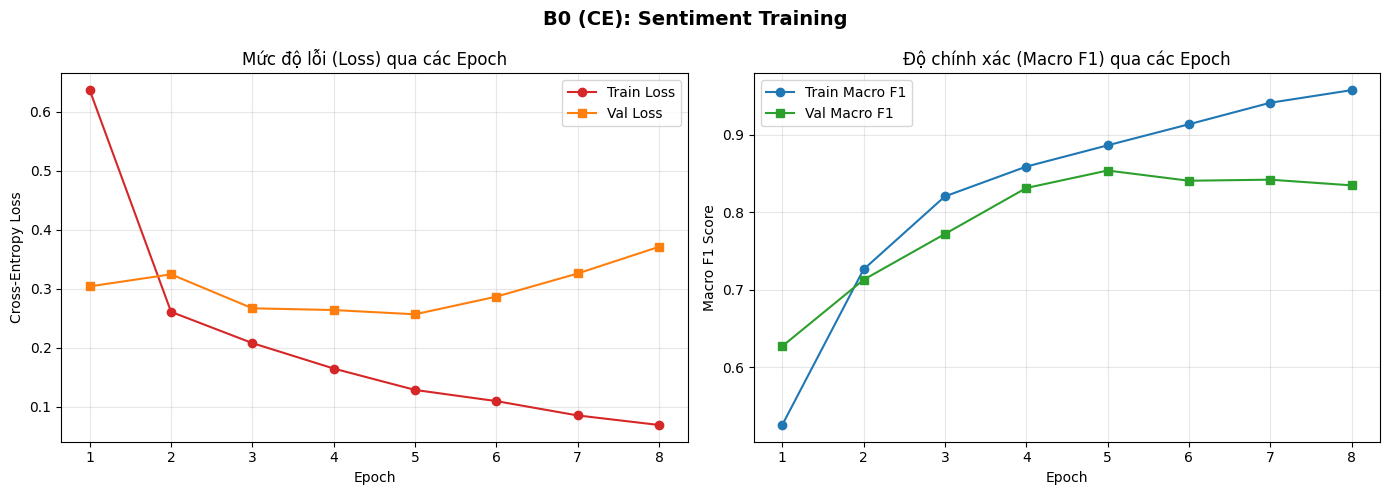


Chẩn đoán validation === B0_CE_Sent (SENTIMENT) ===
              precision    recall  f1-score   support

    Negative     0.9373    0.9759    0.9562       705
     Neutral     0.7049    0.5890    0.6418        73
    Positive     0.9746    0.9540    0.9642       805

    accuracy                         0.9469      1583
   macro avg     0.8723    0.8397    0.8541      1583
weighted avg     0.9456    0.9469    0.9458      1583


=== B0 (CE) SENTIMENT - OLD TEST ===
              precision    recall  f1-score   support

    Negative     0.9344    0.9702    0.9519      1409
     Neutral     0.6560    0.4910    0.5616       167
    Positive     0.9556    0.9484    0.9520      1590

    accuracy                         0.9340      3166
   macro avg     0.8487    0.8032    0.8219      3166
weighted avg     0.9304    0.9340    0.9314      3166



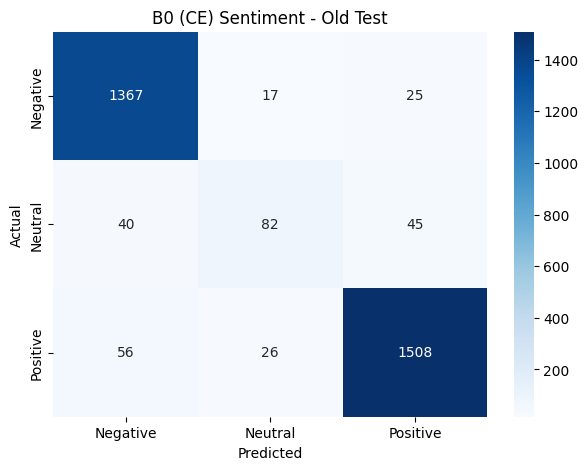


=== B0 (CE) SENTIMENT - NEW TEST ===
              precision    recall  f1-score   support

    Negative     0.9426    0.9836    0.9627      1402
     Neutral     0.7120    0.5633    0.6290       158
    Positive     0.9804    0.9633    0.9717      1606

    accuracy                         0.9523      3166
   macro avg     0.8783    0.8367    0.8545      3166
weighted avg     0.9502    0.9523    0.9506      3166



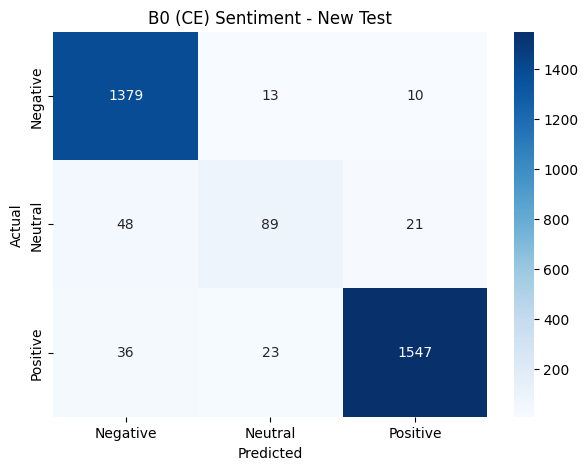

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.7569 | Val Loss: 0.3936 | Train F1: 0.4682 | Val F1: 0.6943
New best (Val F1: 0.6943)
Epoch 02 | Train Loss: 0.3739 | Val Loss: 0.3306 | Train F1: 0.7440 | Val F1: 0.7828
New best (Val F1: 0.7828)
Epoch 03 | Train Loss: 0.3070 | Val Loss: 0.3427 | Train F1: 0.7931 | Val F1: 0.7888
New best (Val F1: 0.7888)
Epoch 04 | Train Loss: 0.2603 | Val Loss: 0.3563 | Train F1: 0.8352 | Val F1: 0.8005
New best (Val F1: 0.8005)
Epoch 05 | Train Loss: 0.2111 | Val Loss: 0.4021 | Train F1: 0.8762 | Val F1: 0.8116
New best (Val F1: 0.8116)
Epoch 06 | Train Loss: 0.1724 | Val Loss: 0.4839 | Train F1: 0.8979 | Val F1: 0.7883
Không cải thiện 1/3
Epoch 07 | Train Loss: 0.1432 | Val Loss: 0.4156 | Train F1: 0.9236 | Val F1: 0.8009
Không cải thiện 2/3
Epoch 08 | Train Loss: 0.1202 | Val Loss: 0.5782 | Train F1: 0.9349 | Val F1: 0.8094
Không cải thiện 3/3
Early stopping tại epoch 8!

Best validation topic Macro F1: 0.8116


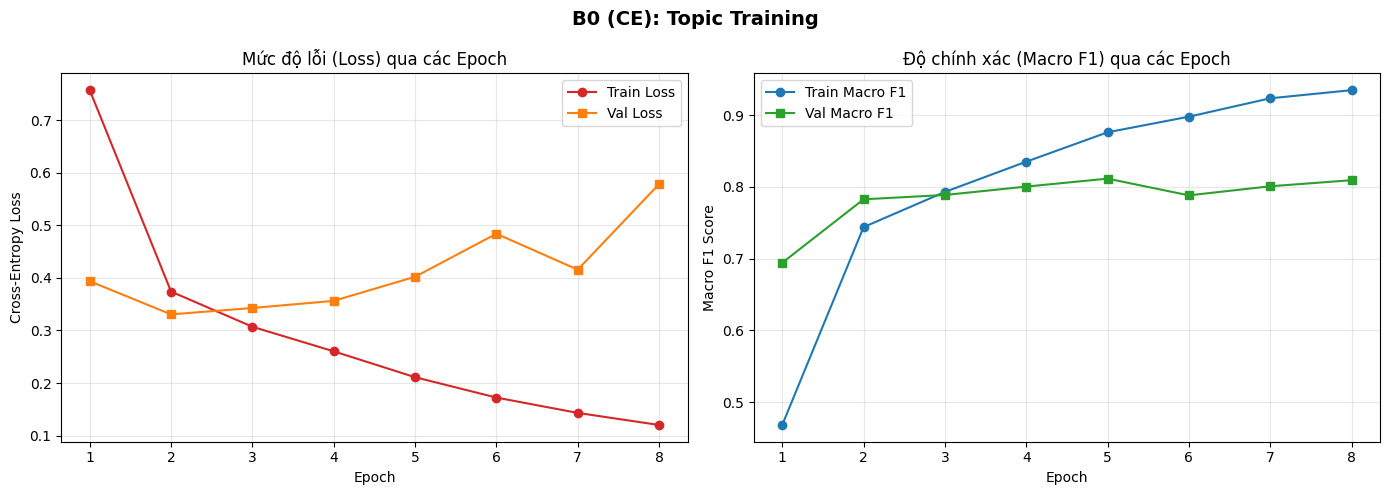


Chẩn đoán validation === B0_CE_Topic (TOPIC) ===
              precision    recall  f1-score   support

    Lecturer     0.9492    0.9418    0.9455      1151
    Training     0.7584    0.8464    0.8000       267
    Facility     0.8933    0.9571    0.9241        70
      Others     0.6912    0.4947    0.5767        95

    accuracy                         0.8996      1583
   macro avg     0.8230    0.8100    0.8116      1583
weighted avg     0.8991    0.8996    0.8979      1583


=== B0 (CE) TOPIC - OLD TEST ===
                  precision    recall  f1-score   support

        Lecturer     0.9396    0.9314    0.9355      2290
Training Program     0.7471    0.7902    0.7681       572
        Facility     0.9079    0.9517    0.9293       145
          Others     0.5540    0.4843    0.5168       159

        accuracy                         0.8844      3166
       macro avg     0.7872    0.7894    0.7874      3166
    weighted avg     0.8840    0.8844    0.8840      3166



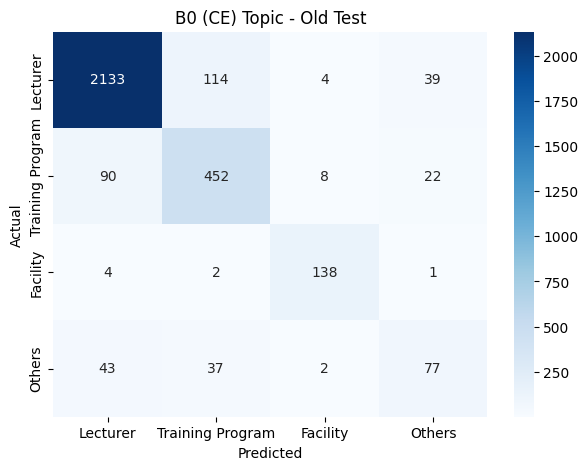


=== B0 (CE) TOPIC - NEW TEST ===
                  precision    recall  f1-score   support

        Lecturer     0.9568    0.9472    0.9520      2293
Training Program     0.8215    0.8409    0.8311       591
        Facility     0.9342    0.9726    0.9530       146
          Others     0.6115    0.6250    0.6182       136

        accuracy                         0.9147      3166
       macro avg     0.8310    0.8464    0.8386      3166
    weighted avg     0.9157    0.9147    0.9151      3166



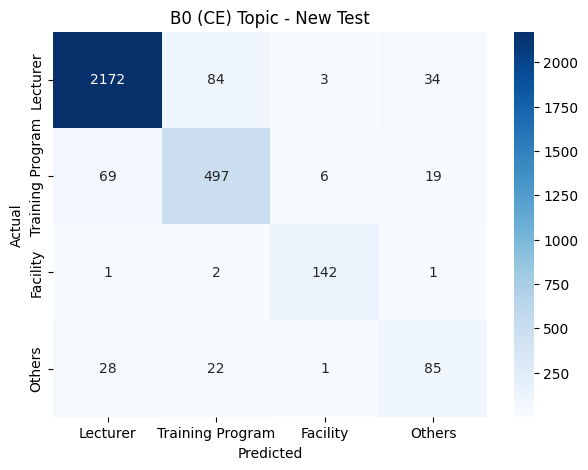


B0 (WCE): Single Task - Weighted Cross Entropy


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.8879 | Val Loss: 0.4480 | Train F1: 0.5363 | Val F1: 0.8248
New best (Val F1: 0.8248)
Epoch 02 | Train Loss: 0.4637 | Val Loss: 0.4977 | Train F1: 0.7783 | Val F1: 0.8068
Không cải thiện 1/3
Epoch 03 | Train Loss: 0.4023 | Val Loss: 0.6198 | Train F1: 0.8199 | Val F1: 0.8371
New best (Val F1: 0.8371)
Epoch 04 | Train Loss: 0.3125 | Val Loss: 0.5618 | Train F1: 0.8663 | Val F1: 0.8436
New best (Val F1: 0.8436)
Epoch 05 | Train Loss: 0.2558 | Val Loss: 0.6563 | Train F1: 0.9032 | Val F1: 0.8546
New best (Val F1: 0.8546)
Epoch 06 | Train Loss: 0.2163 | Val Loss: 0.6698 | Train F1: 0.9281 | Val F1: 0.8592
New best (Val F1: 0.8592)
Epoch 07 | Train Loss: 0.1714 | Val Loss: 0.9321 | Train F1: 0.9413 | Val F1: 0.8524
Không cải thiện 1/3
Epoch 08 | Train Loss: 0.1420 | Val Loss: 0.6221 | Train F1: 0.9570 | Val F1: 0.8447
Không cải thiện 2/3
Epoch 09 | Train Loss: 0.1136 | Val Loss: 0.8721 | Train F1: 0.9635 | Val F1: 0.8427
Không cải thiện 3/3
Early stopping tại epoch 

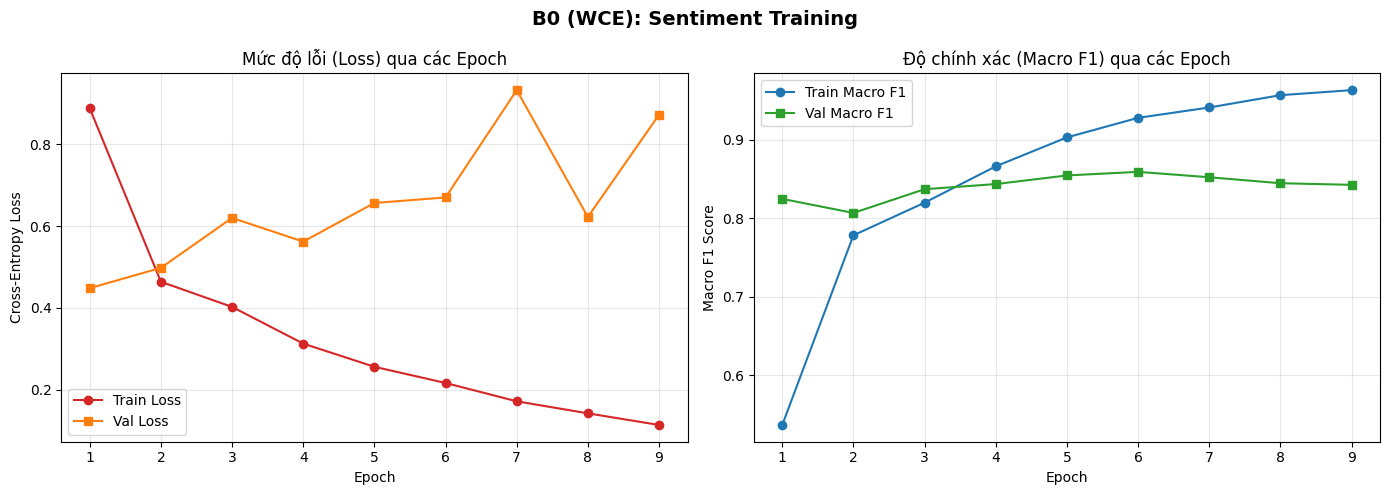


Chẩn đoán validation === B0_WCE_Sent (SENTIMENT) ===
              precision    recall  f1-score   support

    Negative     0.9471    0.9660    0.9565       705
     Neutral     0.7333    0.6027    0.6617        73
    Positive     0.9602    0.9590    0.9596       805

    accuracy                         0.9457      1583
   macro avg     0.8802    0.8426    0.8592      1583
weighted avg     0.9439    0.9457    0.9445      1583


=== B0 (WCE) SENTIMENT - OLD TEST ===
              precision    recall  f1-score   support

    Negative     0.9475    0.9610    0.9542      1409
     Neutral     0.6232    0.5150    0.5639       167
    Positive     0.9443    0.9497    0.9470      1590

    accuracy                         0.9318      3166
   macro avg     0.8383    0.8085    0.8217      3166
weighted avg     0.9288    0.9318    0.9300      3166



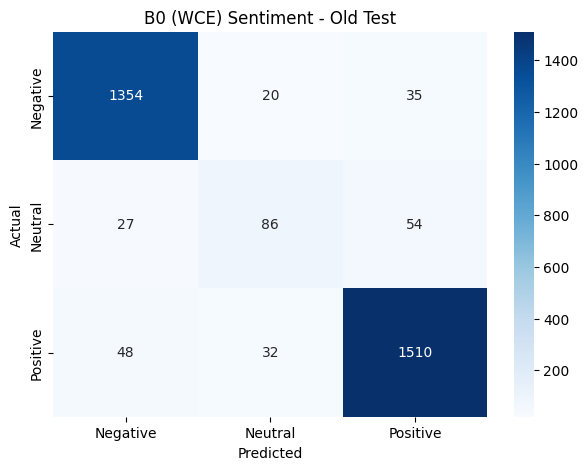


=== B0 (WCE) SENTIMENT - NEW TEST ===
              precision    recall  f1-score   support

    Negative     0.9538    0.9722    0.9629      1402
     Neutral     0.6377    0.5570    0.5946       158
    Positive     0.9662    0.9620    0.9641      1606

    accuracy                         0.9463      3166
   macro avg     0.8526    0.8304    0.8405      3166
weighted avg     0.9443    0.9463    0.9451      3166



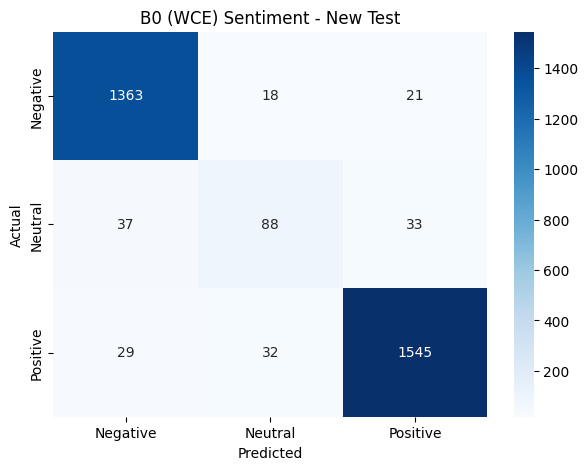

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 1.1176 | Val Loss: 0.7383 | Train F1: 0.4005 | Val F1: 0.7536
New best (Val F1: 0.7536)
Epoch 02 | Train Loss: 0.6128 | Val Loss: 0.5761 | Train F1: 0.7274 | Val F1: 0.7684
New best (Val F1: 0.7684)
Epoch 03 | Train Loss: 0.5039 | Val Loss: 0.5453 | Train F1: 0.7754 | Val F1: 0.7806
New best (Val F1: 0.7806)
Epoch 04 | Train Loss: 0.3918 | Val Loss: 0.8077 | Train F1: 0.8171 | Val F1: 0.7798
Không cải thiện 1/3
Epoch 05 | Train Loss: 0.3336 | Val Loss: 0.6198 | Train F1: 0.8472 | Val F1: 0.7825
New best (Val F1: 0.7825)
Epoch 06 | Train Loss: 0.2618 | Val Loss: 0.9474 | Train F1: 0.8837 | Val F1: 0.7877
New best (Val F1: 0.7877)
Epoch 07 | Train Loss: 0.2137 | Val Loss: 0.9450 | Train F1: 0.9083 | Val F1: 0.8022
New best (Val F1: 0.8022)
Epoch 08 | Train Loss: 0.1718 | Val Loss: 1.2179 | Train F1: 0.9280 | Val F1: 0.8048
New best (Val F1: 0.8048)
Epoch 09 | Train Loss: 0.1492 | Val Loss: 1.2817 | Train F1: 0.9389 | Val F1: 0.7974
Không cải thiện 1/3
Epoch 10 | Tr

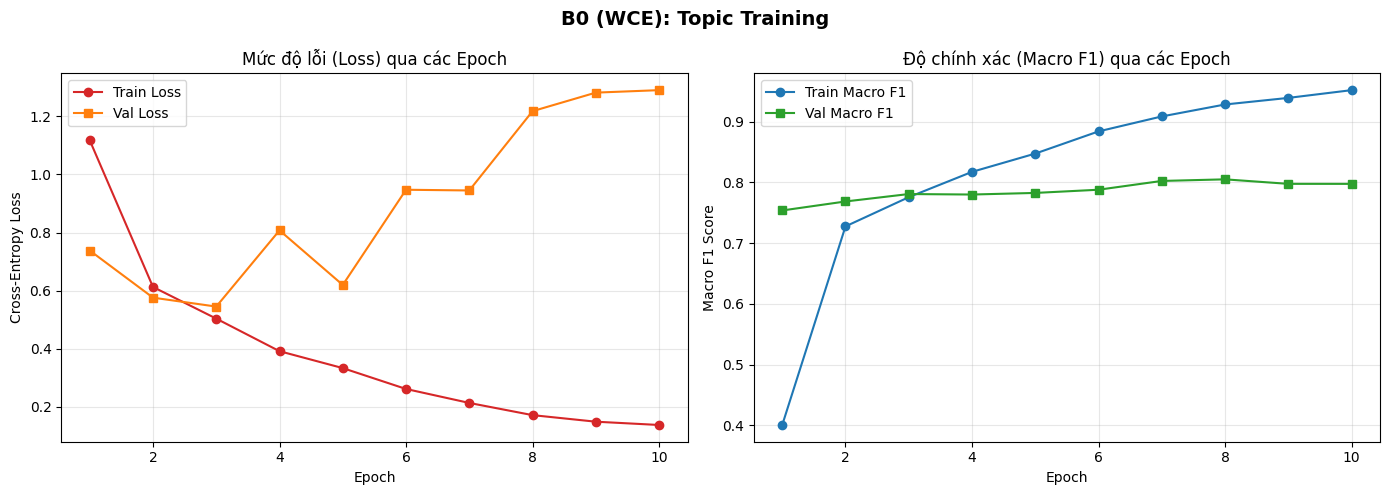


Chẩn đoán validation === B0_WCE_Topic (TOPIC) ===
              precision    recall  f1-score   support

    Lecturer     0.9534    0.9244    0.9387      1151
    Training     0.7134    0.8577    0.7789       267
    Facility     0.9286    0.9286    0.9286        70
      Others     0.6447    0.5158    0.5731        95

    accuracy                         0.8888      1583
   macro avg     0.8100    0.8066    0.8048      1583
weighted avg     0.8933    0.8888    0.8893      1583


=== B0 (WCE) TOPIC - OLD TEST ===
                  precision    recall  f1-score   support

        Lecturer     0.9500    0.9218    0.9357      2290
Training Program     0.7088    0.8339    0.7663       572
        Facility     0.9315    0.9379    0.9347       145
          Others     0.6240    0.4906    0.5493       159

        accuracy                         0.8850      3166
       macro avg     0.8036    0.7961    0.7965      3166
    weighted avg     0.8892    0.8850    0.8857      3166



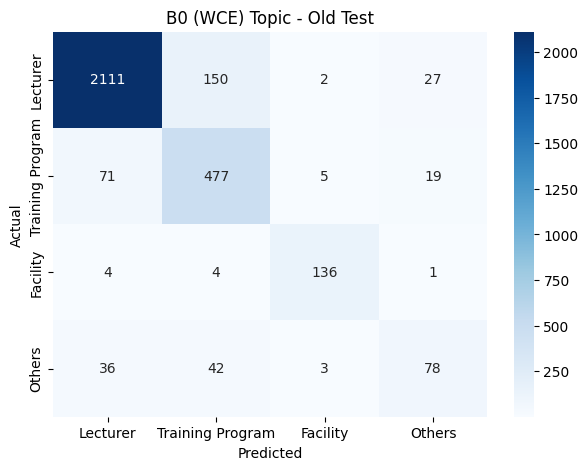


=== B0 (WCE) TOPIC - NEW TEST ===
                  precision    recall  f1-score   support

        Lecturer     0.9698    0.9398    0.9546      2293
Training Program     0.7831    0.8917    0.8339       591
        Facility     0.9589    0.9589    0.9589       146
          Others     0.6960    0.6397    0.6667       136

        accuracy                         0.9188      3166
       macro avg     0.8520    0.8575    0.8535      3166
    weighted avg     0.9227    0.9188    0.9199      3166



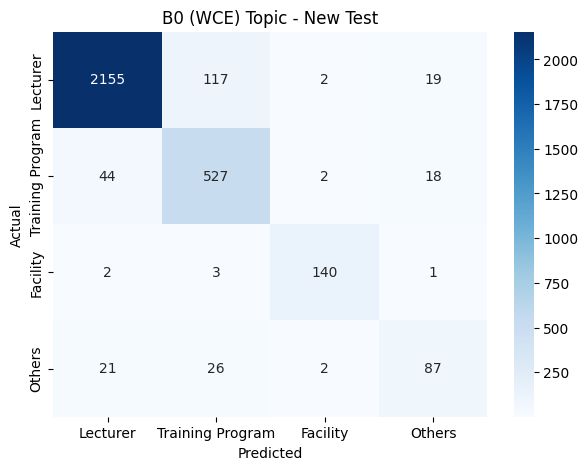


B0 (Focal): Single Task - Focal Loss


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.0415 | Val Loss: 0.0256 | Train F1: 0.4521 | Val F1: 0.7904
New best (Val F1: 0.7904)
Epoch 02 | Train Loss: 0.0190 | Val Loss: 0.0164 | Train F1: 0.7510 | Val F1: 0.8108
New best (Val F1: 0.8108)
Epoch 03 | Train Loss: 0.0148 | Val Loss: 0.0165 | Train F1: 0.7947 | Val F1: 0.8252
New best (Val F1: 0.8252)
Epoch 04 | Train Loss: 0.0105 | Val Loss: 0.0268 | Train F1: 0.8349 | Val F1: 0.8401
New best (Val F1: 0.8401)
Epoch 05 | Train Loss: 0.0070 | Val Loss: 0.0189 | Train F1: 0.8753 | Val F1: 0.8050
Không cải thiện 1/3
Epoch 06 | Train Loss: 0.0050 | Val Loss: 0.0341 | Train F1: 0.9131 | Val F1: 0.8294
Không cải thiện 2/3
Epoch 07 | Train Loss: 0.0033 | Val Loss: 0.0789 | Train F1: 0.9378 | Val F1: 0.8399
Không cải thiện 3/3
Early stopping tại epoch 7!

Best validation sentiment Macro F1: 0.8401


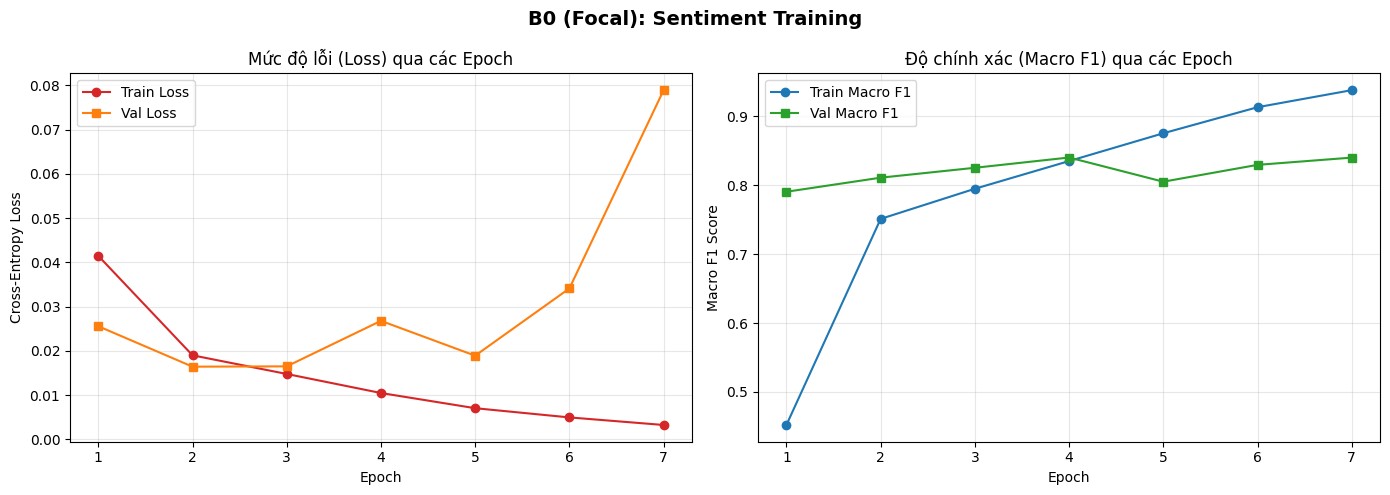


Chẩn đoán validation === B0_Focal_Sent (SENTIMENT) ===
              precision    recall  f1-score   support

    Negative     0.9451    0.9518    0.9484       705
     Neutral     0.6286    0.6027    0.6154        73
    Positive     0.9577    0.9553    0.9565       805

    accuracy                         0.9375      1583
   macro avg     0.8438    0.8366    0.8401      1583
weighted avg     0.9369    0.9375    0.9372      1583


=== B0 (FOCAL) SENTIMENT - OLD TEST ===
              precision    recall  f1-score   support

    Negative     0.9371    0.9624    0.9496      1409
     Neutral     0.6438    0.5629    0.6006       167
    Positive     0.9599    0.9497    0.9548      1590

    accuracy                         0.9349      3166
   macro avg     0.8470    0.8250    0.8350      3166
weighted avg     0.9331    0.9349    0.9338      3166



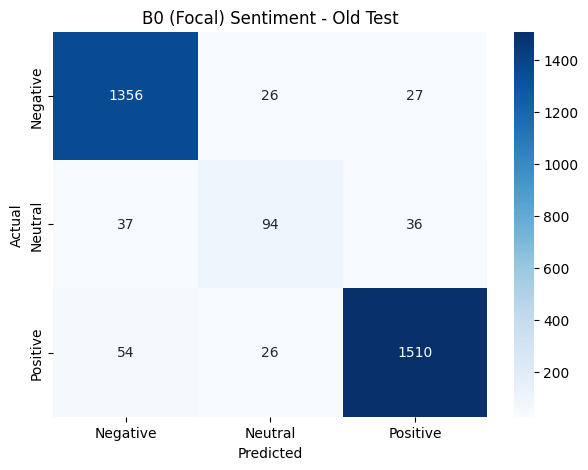


=== B0 (FOCAL) SENTIMENT - NEW TEST ===
              precision    recall  f1-score   support

    Negative     0.9454    0.9757    0.9603      1402
     Neutral     0.6575    0.6076    0.6316       158
    Positive     0.9816    0.9614    0.9714      1606

    accuracy                         0.9501      3166
   macro avg     0.8615    0.8482    0.8544      3166
weighted avg     0.9494    0.9501    0.9495      3166



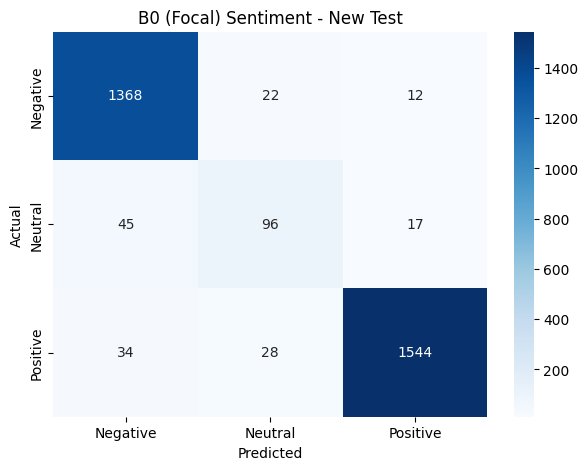

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.0358 | Val Loss: 0.0182 | Train F1: 0.3631 | Val F1: 0.7573
New best (Val F1: 0.7573)
Epoch 02 | Train Loss: 0.0175 | Val Loss: 0.0137 | Train F1: 0.6812 | Val F1: 0.7639
New best (Val F1: 0.7639)
Epoch 03 | Train Loss: 0.0137 | Val Loss: 0.0166 | Train F1: 0.7353 | Val F1: 0.7617
Không cải thiện 1/3
Epoch 04 | Train Loss: 0.0114 | Val Loss: 0.0166 | Train F1: 0.7680 | Val F1: 0.7756
New best (Val F1: 0.7756)
Epoch 05 | Train Loss: 0.0083 | Val Loss: 0.0203 | Train F1: 0.7971 | Val F1: 0.7513
Không cải thiện 1/3
Epoch 06 | Train Loss: 0.0065 | Val Loss: 0.0222 | Train F1: 0.8252 | Val F1: 0.7783
New best (Val F1: 0.7783)
Epoch 07 | Train Loss: 0.0047 | Val Loss: 0.0294 | Train F1: 0.8494 | Val F1: 0.7754
Không cải thiện 1/3
Epoch 08 | Train Loss: 0.0038 | Val Loss: 0.0330 | Train F1: 0.8656 | Val F1: 0.7842
New best (Val F1: 0.7842)
Epoch 09 | Train Loss: 0.0028 | Val Loss: 0.0441 | Train F1: 0.8929 | Val F1: 0.7719
Không cải thiện 1/3
Epoch 10 | Train Loss: 0.

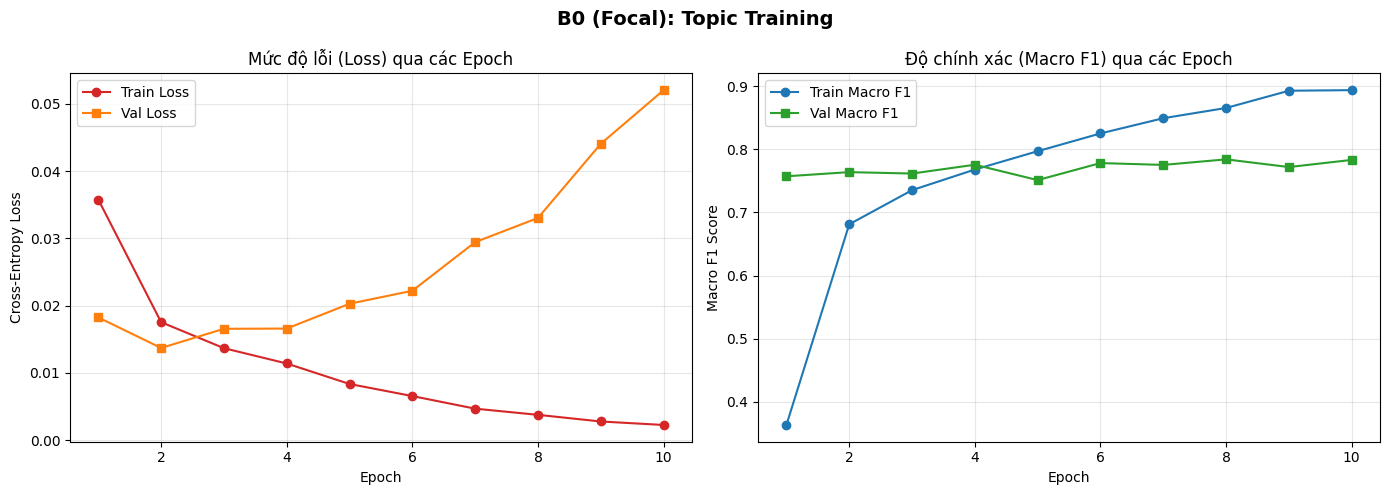


Chẩn đoán validation === B0_Focal_Topic (TOPIC) ===
              precision    recall  f1-score   support

    Lecturer     0.9508    0.9062    0.9279      1151
    Training     0.7347    0.8090    0.7701       267
    Facility     0.8800    0.9429    0.9103        70
      Others     0.4786    0.5895    0.5283        95

    accuracy                         0.8724      1583
   macro avg     0.7610    0.8119    0.7842      1583
weighted avg     0.8829    0.8724    0.8765      1583


=== B0 (FOCAL) TOPIC - OLD TEST ===
                  precision    recall  f1-score   support

        Lecturer     0.9516    0.9017    0.9260      2290
Training Program     0.7348    0.7797    0.7566       572
        Facility     0.9184    0.9310    0.9247       145
          Others     0.4174    0.6352    0.5037       159

        accuracy                         0.8677      3166
       macro avg     0.7555    0.8119    0.7777      3166
    weighted avg     0.8841    0.8677    0.8741      3166



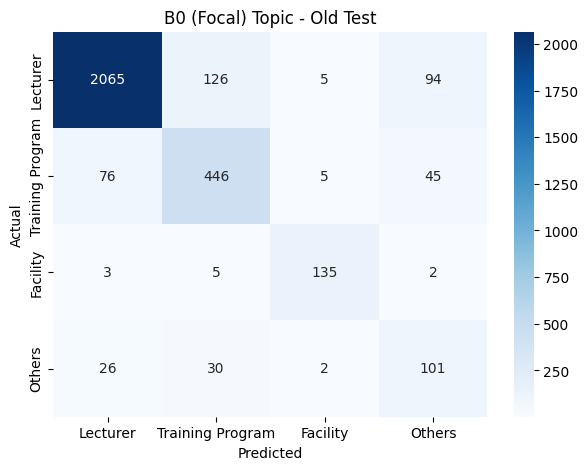


=== B0 (FOCAL) TOPIC - NEW TEST ===
                  precision    recall  f1-score   support

        Lecturer     0.9700    0.9180    0.9433      2293
Training Program     0.7990    0.8206    0.8097       591
        Facility     0.9456    0.9521    0.9488       146
          Others     0.4380    0.7794    0.5608       136

        accuracy                         0.8955      3166
       macro avg     0.7882    0.8675    0.8157      3166
    weighted avg     0.9141    0.8955    0.9022      3166



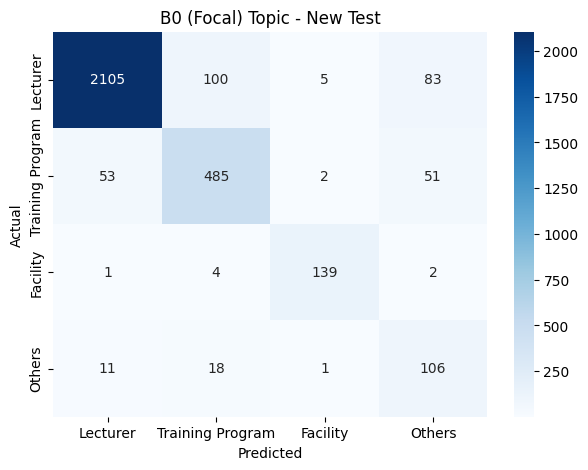


B0 (ASL): Single Task - Asymmetric Loss


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.5209 | Val Loss: 0.2302 | Train F1: 0.4742 | Val F1: 0.7581
New best (Val F1: 0.7581)
Epoch 02 | Train Loss: 0.2221 | Val Loss: 0.1762 | Train F1: 0.7478 | Val F1: 0.8224
New best (Val F1: 0.8224)
Epoch 03 | Train Loss: 0.1677 | Val Loss: 0.1876 | Train F1: 0.8054 | Val F1: 0.8393
New best (Val F1: 0.8393)
Epoch 04 | Train Loss: 0.1361 | Val Loss: 0.1687 | Train F1: 0.8316 | Val F1: 0.8624
New best (Val F1: 0.8624)
Epoch 05 | Train Loss: 0.1083 | Val Loss: 0.1722 | Train F1: 0.8681 | Val F1: 0.8527
Không cải thiện 1/3
Epoch 06 | Train Loss: 0.0842 | Val Loss: 0.1966 | Train F1: 0.9035 | Val F1: 0.8483
Không cải thiện 2/3
Epoch 07 | Train Loss: 0.0691 | Val Loss: 0.2085 | Train F1: 0.9225 | Val F1: 0.8522
Không cải thiện 3/3
Early stopping tại epoch 7!

Best validation sentiment Macro F1: 0.8624


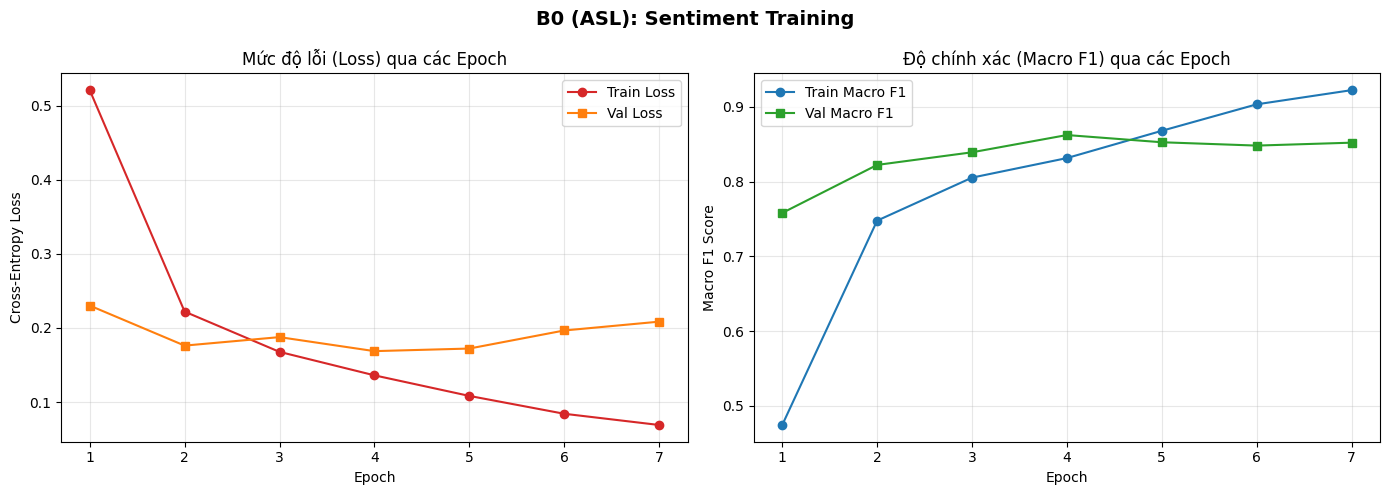


Chẩn đoán validation === B0_ASL_Sent (SENTIMENT) ===
              precision    recall  f1-score   support

    Negative     0.9628    0.9532    0.9579       705
     Neutral     0.6163    0.7260    0.6667        73
    Positive     0.9662    0.9590    0.9626       805

    accuracy                         0.9457      1583
   macro avg     0.8484    0.8794    0.8624      1583
weighted avg     0.9485    0.9457    0.9469      1583


=== B0 (ASL) SENTIMENT - OLD TEST ===
              precision    recall  f1-score   support

    Negative     0.9505    0.9411    0.9458      1409
     Neutral     0.5149    0.6228    0.5637       167
    Positive     0.9554    0.9428    0.9490      1590

    accuracy                         0.9251      3166
   macro avg     0.8069    0.8355    0.8195      3166
weighted avg     0.9300    0.9251    0.9273      3166



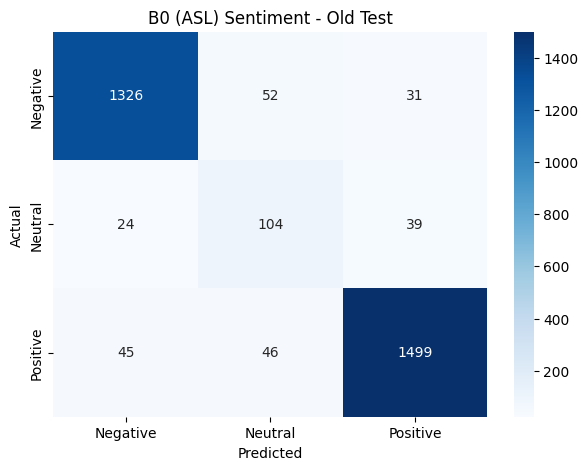


=== B0 (ASL) SENTIMENT - NEW TEST ===
              precision    recall  f1-score   support

    Negative     0.9591    0.9544    0.9567      1402
     Neutral     0.5396    0.6899    0.6056       158
    Positive     0.9764    0.9539    0.9650      1606

    accuracy                         0.9409      3166
   macro avg     0.8251    0.8660    0.8424      3166
weighted avg     0.9470    0.9409    0.9434      3166



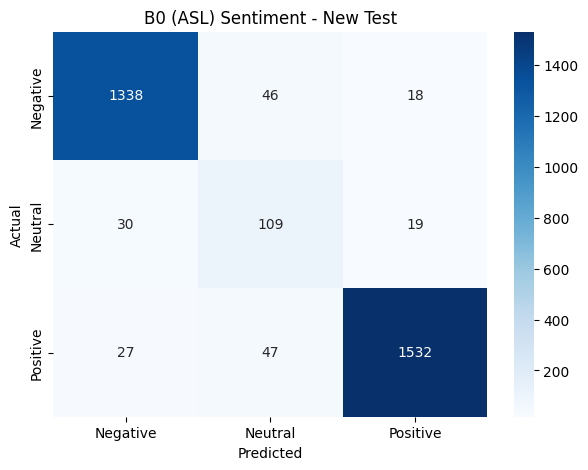

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01 | Train Loss: 0.8581 | Val Loss: 0.3414 | Train F1: 0.3065 | Val F1: 0.6821
New best (Val F1: 0.6821)
Epoch 02 | Train Loss: 0.3298 | Val Loss: 0.2893 | Train F1: 0.7225 | Val F1: 0.7846
New best (Val F1: 0.7846)
Epoch 03 | Train Loss: 0.2739 | Val Loss: 0.2514 | Train F1: 0.7711 | Val F1: 0.7926
New best (Val F1: 0.7926)
Epoch 04 | Train Loss: 0.2302 | Val Loss: 0.2792 | Train F1: 0.8021 | Val F1: 0.7733
Không cải thiện 1/3
Epoch 05 | Train Loss: 0.1885 | Val Loss: 0.2844 | Train F1: 0.8366 | Val F1: 0.7888
Không cải thiện 2/3
Epoch 06 | Train Loss: 0.1536 | Val Loss: 0.3289 | Train F1: 0.8640 | Val F1: 0.7992
New best (Val F1: 0.7992)
Epoch 07 | Train Loss: 0.1245 | Val Loss: 0.3567 | Train F1: 0.8870 | Val F1: 0.8011
New best (Val F1: 0.8011)
Epoch 08 | Train Loss: 0.1083 | Val Loss: 0.3671 | Train F1: 0.9063 | Val F1: 0.7933
Không cải thiện 1/3
Epoch 09 | Train Loss: 0.0854 | Val Loss: 0.4145 | Train F1: 0.9285 | Val F1: 0.7951
Không cải thiện 2/3
Epoch 10 | Train Loss: 0.

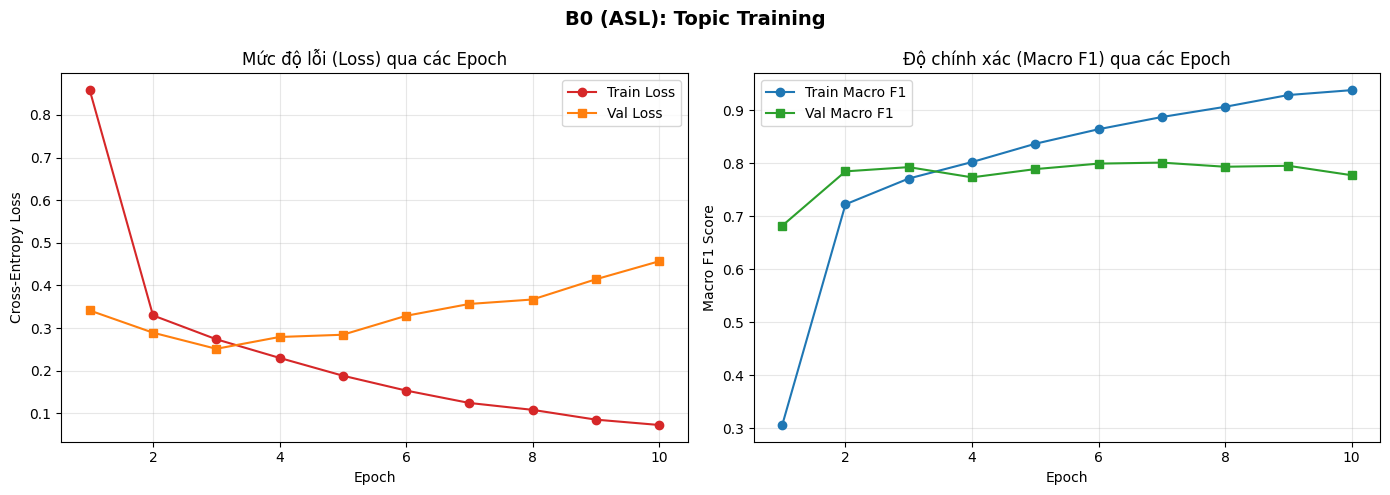


Chẩn đoán validation === B0_ASL_Topic (TOPIC) ===
              precision    recall  f1-score   support

    Lecturer     0.9512    0.9305    0.9407      1151
    Training     0.7482    0.7790    0.7633       267
    Facility     0.9412    0.9143    0.9275        70
      Others     0.5315    0.6211    0.5728        95

    accuracy                         0.8857      1583
   macro avg     0.7930    0.8112    0.8011      1583
weighted avg     0.8913    0.8857    0.8881      1583


=== B0 (ASL) TOPIC - OLD TEST ===
                  precision    recall  f1-score   support

        Lecturer     0.9490    0.9188    0.9337      2290
Training Program     0.7513    0.7762    0.7635       572
        Facility     0.9574    0.9310    0.9441       145
          Others     0.4055    0.5535    0.4681       159

        accuracy                         0.8752      3166
       macro avg     0.7658    0.7949    0.7773      3166
    weighted avg     0.8864    0.8752    0.8800      3166



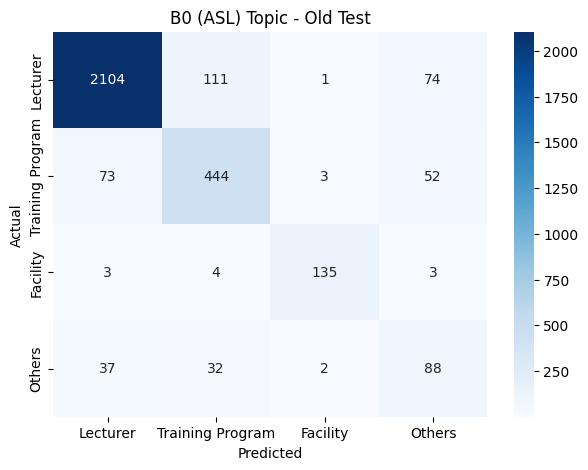


=== B0 (ASL) TOPIC - NEW TEST ===
                  precision    recall  f1-score   support

        Lecturer     0.9680    0.9359    0.9517      2293
Training Program     0.8206    0.8206    0.8206       591
        Facility     0.9787    0.9452    0.9617       146
          Others     0.4424    0.7059    0.5439       136

        accuracy                         0.9049      3166
       macro avg     0.8024    0.8519    0.8195      3166
    weighted avg     0.9184    0.9049    0.9102      3166



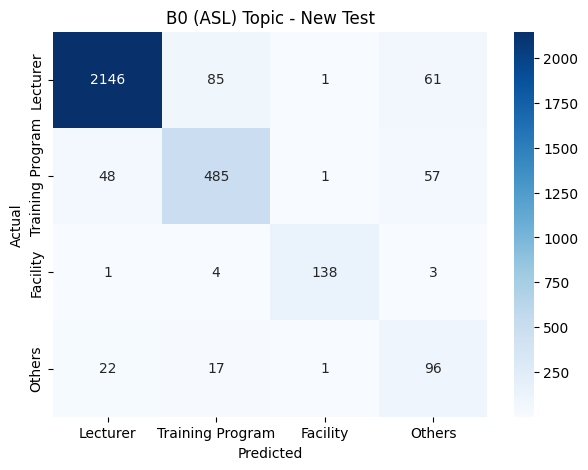

In [ ]:
class BaselineModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(MODEL_NAME)
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(self.encoder.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(self.dropout(out.last_hidden_state[:, 0, :]))

def train_single_task(model, train_loader, val_loader, loss_fn, task, model_name="b0", patience=3):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * WARMUP_RATIO), total_steps)
    
    model.to(DEVICE)
    best_f1, no_improve, history = 0.0, 0, []

    for epoch in range(1, EPOCHS + 1):
        # PHA 1: HUẤN LUYỆN (TRAINING)
        model.train()
        train_loss = 0
        train_preds, train_targets = [], []
        optimizer.zero_grad()
        
        for step, batch in enumerate(train_loader):
            ids, mask = batch["input_ids"].to(DEVICE), batch["attention_mask"].to(DEVICE)
            targets = batch[task].to(DEVICE)
            
            logits = model(ids, mask)
            loss = loss_fn(logits, targets)
            (loss / ACCUM_STEPS).backward()
            # nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            # optimizer.step()
            # scheduler.step()
            # CẬP NHẬT TRỌNG SỐ KHI ĐỦ SỐ BATCH CỘNG DỒN
            if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad() # Xóa gradient để đón mẻ mới
            
            train_loss += loss.item()
            train_preds.extend(logits.argmax(-1).cpu().tolist())
            train_targets.extend(targets.cpu().tolist())

        # Tính toán chỉ số Train
        train_loss = train_loss / len(train_loader)
        train_acc = accuracy_score(train_targets, train_preds)
        train_f1 = f1_score(train_targets, train_preds, average="macro")

        # PHA 2: KIỂM CHỨNG (VALIDATION)
        model.eval()
        val_loss = 0
        val_preds, val_targets = [], []
        
        with torch.no_grad():
            for batch in val_loader:
                ids = batch["input_ids"].to(DEVICE)
                mask = batch["attention_mask"].to(DEVICE)
                targets = batch[task].to(DEVICE) # <-- Cần lấy targets để tính val_loss
                
                logits = model(ids, mask)
                loss = loss_fn(logits, targets)
                
                val_loss += loss.item()
                val_preds.extend(logits.argmax(-1).cpu().tolist())
                val_targets.extend(targets.cpu().tolist())

        # Tính toán chỉ số Validation
        val_loss = val_loss / len(val_loader)
        val_acc = accuracy_score(val_targets, val_preds)
        val_f1 = f1_score(val_targets, val_preds, average="macro")
        
        # PHA 3: LƯU LỊCH SỬ VÀ IN KẾT QUẢ
        history.append({
            "epoch": epoch, 
            "train_loss": train_loss, "val_loss": val_loss,
            # "train_acc": train_acc, "val_acc": val_acc,
            "train_f1": train_f1, "val_f1": val_f1
        })
        
        # Format chuỗi in ra y hệt yêu cầu của bạn
        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f}")

        # Early Stopping dựa trên Val F1
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
            print(f"New best (Val F1: {best_f1:.4f})")
        else:
            no_improve += 1
            print(f"Không cải thiện {no_improve}/{patience}")
            if no_improve >= patience:
                print(f"Early stopping tại epoch {epoch}!")
                break

    # Load lại weights tốt nhất trước khi trả về
    model.load_state_dict(best_state)
    torch.save(best_state, f"{model_name}_best.pt")
    print(f"\nBest validation {task} Macro F1: {best_f1:.4f}")
    
    return model, pd.DataFrame(history), best_f1


# Khởi tạo các hàm loss
ce_sent  = nn.CrossEntropyLoss()
ce_topic = nn.CrossEntropyLoss()

wce_sent  = nn.CrossEntropyLoss(weight=sent_weights.to(DEVICE))
wce_topic = nn.CrossEntropyLoss(weight=topic_weights.to(DEVICE))

focal_sent  = FocalLoss(alpha=sent_focal_alpha,  gamma=2.0).to(DEVICE)
focal_topic = FocalLoss(alpha=topic_focal_alpha, gamma=3.0).to(DEVICE)

asl_sent = ClassSpecificAsymmetricLoss(
    gamma_neg_list=[0.0, 4.0, 0.0],  
    gamma_pos_list=[2.0, 1.0, 2.0]   
).to(DEVICE)

asl_topic = ClassSpecificAsymmetricLoss(
    gamma_neg_list=[0.0, 0.0, 0.0, 4.0], 
    gamma_pos_list=[2.0, 2.0, 2.0, 1.0]
).to(DEVICE)

# CHẠY THỰC NGHIỆM B0 - SINGLE TASK LEARNING (ĐỘC LẬP TỪNG TASK)
results_old_test_stl = {}
results_new_test_stl = {}

# HÀM BỔ TRỢ: Lấy F1 Macro từ Dictionary Report để nhét vào bảng
def get_macro_f1_from_report(report_dict):
    return report_dict["macro avg"]["f1-score"]


# ── 1. B0 (CE): Standard Cross Entropy ──
print("\n" + "="*50)
print("B0 (CE): Single Task - Standard Cross Entropy")
print("="*50)
# >> Sentiment
model_b0_ce_sent = BaselineModel(num_classes=NUM_SENTIMENT).to(DEVICE)
model_b0_ce_sent, hist_b0_ce_sent, _ = train_single_task(model_b0_ce_sent, train_loader, val_loader, 
                                                         ce_sent, task="sentiment", model_name="B0_CE_Sent")
plot_training_history(hist_b0_ce_sent, title="B0 (CE): Sentiment Training")
diagnose_validation_single_task(model_b0_ce_sent, val_loader, "B0_CE_Sent", task="sentiment")
rep_sent_old_ce = evaluate_and_plot(model_b0_ce_sent, test_loader, "sentiment", SENT_NAMES, "B0 (CE) Sentiment - Old Test")
rep_sent_new_ce = evaluate_and_plot(model_b0_ce_sent, test_loader1, "sentiment", SENT_NAMES, "B0 (CE) Sentiment - New Test")

# >> Topic
model_b0_ce_topic = BaselineModel(num_classes=NUM_TOPIC).to(DEVICE)
model_b0_ce_topic, hist_b0_ce_topic, _ = train_single_task(model_b0_ce_topic, train_loader, val_loader, 
                                                           ce_topic, task="topic", model_name="B0_CE_Topic")
plot_training_history(hist_b0_ce_topic, title="B0 (CE): Topic Training")
diagnose_validation_single_task(model_b0_ce_topic, val_loader, "B0_CE_Topic", task="topic")
rep_topic_old_ce = evaluate_and_plot(model_b0_ce_topic, test_loader, "topic", TOPIC_NAMES, "B0 (CE) Topic - Old Test")
rep_topic_new_ce = evaluate_and_plot(model_b0_ce_topic, test_loader1, "topic", TOPIC_NAMES, "B0 (CE) Topic - New Test")

# >> Đóng gói kết quả (Giả lập cấu trúc MTL để in bảng)
results_old_test_stl["B0_CE"] = {
    "sent_macro_f1": get_macro_f1_from_report(rep_sent_old_ce),
    "topic_macro_f1": get_macro_f1_from_report(rep_topic_old_ce),
    "sent_report": rep_sent_old_ce,
    "topic_report": rep_topic_old_ce
}
results_new_test_stl["B0_CE"] = {
    "sent_macro_f1": get_macro_f1_from_report(rep_sent_new_ce),
    "topic_macro_f1": get_macro_f1_from_report(rep_topic_new_ce),
    "sent_report": rep_sent_new_ce,
    "topic_report": rep_topic_new_ce
}


# ── 2. B0 (WCE): Weighted Cross Entropy ──
print("\n" + "="*50)
print("B0 (WCE): Single Task - Weighted Cross Entropy")
print("="*50)
# >> Sentiment
model_b0_wce_sent = BaselineModel(num_classes=NUM_SENTIMENT).to(DEVICE)
model_b0_wce_sent, hist_b0_wce_sent, _ = train_single_task(model_b0_wce_sent, train_loader, val_loader, 
                                                           wce_sent, task="sentiment", model_name="B0_WCE_Sent")
plot_training_history(hist_b0_wce_sent, title="B0 (WCE): Sentiment Training")
diagnose_validation_single_task(model_b0_wce_sent, val_loader, "B0_WCE_Sent", task="sentiment")
rep_sent_old_wce = evaluate_and_plot(model_b0_wce_sent, test_loader, "sentiment", SENT_NAMES, "B0 (WCE) Sentiment - Old Test")
rep_sent_new_wce = evaluate_and_plot(model_b0_wce_sent, test_loader1, "sentiment", SENT_NAMES, "B0 (WCE) Sentiment - New Test")

# >> Topic
model_b0_wce_topic = BaselineModel(num_classes=NUM_TOPIC).to(DEVICE)
model_b0_wce_topic, hist_b0_wce_topic, _ = train_single_task(model_b0_wce_topic, train_loader, val_loader, 
                                                             wce_topic, task="topic", model_name="B0_WCE_Topic")
plot_training_history(hist_b0_wce_topic, title="B0 (WCE): Topic Training")
diagnose_validation_single_task(model_b0_wce_topic, val_loader, "B0_WCE_Topic", task="topic")
rep_topic_old_wce = evaluate_and_plot(model_b0_wce_topic, test_loader, "topic", TOPIC_NAMES, "B0 (WCE) Topic - Old Test")
rep_topic_new_wce = evaluate_and_plot(model_b0_wce_topic, test_loader1, "topic", TOPIC_NAMES, "B0 (WCE) Topic - New Test")

results_old_test_stl["B0_WCE"] = {
    "sent_macro_f1": get_macro_f1_from_report(rep_sent_old_wce),
    "topic_macro_f1": get_macro_f1_from_report(rep_topic_old_wce),
    "sent_report": rep_sent_old_wce,
    "topic_report": rep_topic_old_wce
}
results_new_test_stl["B0_WCE"] = {
    "sent_macro_f1": get_macro_f1_from_report(rep_sent_new_wce),
    "topic_macro_f1": get_macro_f1_from_report(rep_topic_new_wce),
    "sent_report": rep_sent_new_wce,
    "topic_report": rep_topic_new_wce
}


# ── 3. B0 (Focal): Focal Loss ──
print("\n" + "="*50)
print("B0 (Focal): Single Task - Focal Loss")
print("="*50)
# >> Sentiment
model_b0_focal_sent = BaselineModel(num_classes=NUM_SENTIMENT).to(DEVICE)
model_b0_focal_sent, hist_b0_focal_sent, _ = train_single_task(model_b0_focal_sent, train_loader, val_loader, 
                                                               focal_sent, task="sentiment", model_name="B0_Focal_Sent")
plot_training_history(hist_b0_focal_sent, title="B0 (Focal): Sentiment Training")
diagnose_validation_single_task(model_b0_focal_sent, val_loader, "B0_Focal_Sent", task="sentiment")
rep_sent_old_focal = evaluate_and_plot(model_b0_focal_sent, test_loader, "sentiment", SENT_NAMES, "B0 (Focal) Sentiment - Old Test")
rep_sent_new_focal = evaluate_and_plot(model_b0_focal_sent, test_loader1, "sentiment", SENT_NAMES, "B0 (Focal) Sentiment - New Test")

# >> Topic
model_b0_focal_topic = BaselineModel(num_classes=NUM_TOPIC).to(DEVICE)
model_b0_focal_topic, hist_b0_focal_topic, _ = train_single_task(model_b0_focal_topic, train_loader, val_loader, 
                                                                 focal_topic, task="topic", model_name="B0_Focal_Topic")
plot_training_history(hist_b0_focal_topic, title="B0 (Focal): Topic Training")
diagnose_validation_single_task(model_b0_focal_topic, val_loader, "B0_Focal_Topic", task="topic")
rep_topic_old_focal = evaluate_and_plot(model_b0_focal_topic, test_loader, "topic", TOPIC_NAMES, "B0 (Focal) Topic - Old Test")
rep_topic_new_focal = evaluate_and_plot(model_b0_focal_topic, test_loader1, "topic", TOPIC_NAMES, "B0 (Focal) Topic - New Test")

results_old_test_stl["B0_Focal"] = {
    "sent_macro_f1": get_macro_f1_from_report(rep_sent_old_focal),
    "topic_macro_f1": get_macro_f1_from_report(rep_topic_old_focal),
    "sent_report": rep_sent_old_focal,
    "topic_report": rep_topic_old_focal
}
results_new_test_stl["B0_Focal"] = {
    "sent_macro_f1": get_macro_f1_from_report(rep_sent_new_focal),
    "topic_macro_f1": get_macro_f1_from_report(rep_topic_new_focal),
    "sent_report": rep_sent_new_focal,
    "topic_report": rep_topic_new_focal
}


# ── 4. B0 (ASL): Asymmetric Loss ──
print("\n" + "="*50)
print("B0 (ASL): Single Task - Asymmetric Loss")
print("="*50)
# >> Sentiment
model_b0_asl_sent = BaselineModel(num_classes=NUM_SENTIMENT).to(DEVICE)
model_b0_asl_sent, hist_b0_asl_sent, _ = train_single_task(model_b0_asl_sent, train_loader, val_loader, 
                                                           asl_sent, task="sentiment", model_name="B0_ASL_Sent")
plot_training_history(hist_b0_asl_sent, title="B0 (ASL): Sentiment Training")
diagnose_validation_single_task(model_b0_asl_sent, val_loader, "B0_ASL_Sent", task="sentiment")
rep_sent_old_asl = evaluate_and_plot(model_b0_asl_sent, test_loader, "sentiment", SENT_NAMES, "B0 (ASL) Sentiment - Old Test")
rep_sent_new_asl = evaluate_and_plot(model_b0_asl_sent, test_loader1, "sentiment", SENT_NAMES, "B0 (ASL) Sentiment - New Test")

# >> Topic
model_b0_asl_topic = BaselineModel(num_classes=NUM_TOPIC).to(DEVICE)
model_b0_asl_topic, hist_b0_asl_topic, _ = train_single_task(model_b0_asl_topic, train_loader, val_loader, 
                                                             asl_topic, task="topic", model_name="B0_ASL_Topic")
plot_training_history(hist_b0_asl_topic, title="B0 (ASL): Topic Training")
diagnose_validation_single_task(model_b0_asl_topic, val_loader, "B0_ASL_Topic", task="topic")
rep_topic_old_asl = evaluate_and_plot(model_b0_asl_topic, test_loader, "topic", TOPIC_NAMES, "B0 (ASL) Topic - Old Test")
rep_topic_new_asl = evaluate_and_plot(model_b0_asl_topic, test_loader1, "topic", TOPIC_NAMES, "B0 (ASL) Topic - New Test")

results_old_test_stl["B0_ASL"] = {
    "sent_macro_f1": get_macro_f1_from_report(rep_sent_old_asl),
    "topic_macro_f1": get_macro_f1_from_report(rep_topic_old_asl),
    "sent_report": rep_sent_old_asl,
    "topic_report": rep_topic_old_asl
}
results_new_test_stl["B0_ASL"] = {
    "sent_macro_f1": get_macro_f1_from_report(rep_sent_new_asl),
    "topic_macro_f1": get_macro_f1_from_report(rep_topic_new_asl),
    "sent_report": rep_sent_new_asl,
    "topic_report": rep_topic_new_asl
}